# Design A -- knowledge-driven status inference with external evaluation

Three strictly separated channels:

1. **Features / objects:** the knowledge topology KT0 (nodes, links) defines the ground atoms. Baseline attributes (lon, lat, act0; w_g, w_0) describe KT0 and are used for forging and reporting.
2. **Facts (partial KT1, symbolic only):** the down-link observation and a revealed fraction of operational links -- injected as *clamped evidence* on the Up atoms. No numeric KT1 values enter the KB.
3. **Ground truth (evaluation only):** DF1(v) = act1/act0 and rho(l) = w1/w0 from the forged event -- never seen in training.

**Implementation notes (each one was necessary -- found by experiment):**

- **Propositional grounding (TruthTable):** per-atom trainable truth degrees. For a static, single-topology case study, optimizing these logits *is* differentiable model finding. (Feature-MLP predicates suffer optimization pathologies here: shared-function coupling and saturation deadlocks.)
- **Evidence clamping:** observed atoms are constants, not parameters. Otherwise the optimizer "satisfies" rules by bending the evidence (e.g. raising the down link back up) instead of inferring statuses.
- **Closed-world defaults** (healthy/up unless evidence) select the *minimal* model -- without them, "everything affected" satisfies the monotone rules perfectly.
- **Stage-wise training (differentiable forward chaining):** infer Affected first (with Up clamped), then freeze it and infer AffLink. Mirrors the T_P fixpoint and removes the fuzzy-implication pathology where a rule satisfies itself by falsifying its antecedent.
- **No contrapositives (R2', R3'):** under fuzzy semantics they are not redundant; combined with defaults they propagate "unaffectedness" backward and collapse inference.
- **Split conjunctive consequents:** ~Up(l) => Aff(s) & Aff(t) becomes two implications; AndProd scales each conjunct's gradient by the other (deadlock at low truth values).
- **Complete diag groups per rule:** quantifying a subset of a larger diag group silently broadcasts (grid semantics) and smears gradients across unrelated atoms.


In [1]:
import math, random
import numpy as np
import networkx as nx
import torch
import ltn
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score, f1_score

device = torch.device('cpu')

raw_nodes = {
    "Hannover": (9.80, 52.39), "Frankfurt": (8.66, 50.14), "Hamburg": (10.08, 53.55),
    "Norden": (7.21, 53.60), "Bremen": (8.80, 53.08), "Berlin": (13.48, 52.52),
    "Muenchen": (11.55, 48.15), "Ulm": (9.99, 48.40), "Nuernberg": (11.08, 49.45),
    "Stuttgart": (9.12, 48.73), "Karlsruhe": (8.41, 49.01), "Mannheim": (8.49, 49.49),
    "Essen": (7.00, 51.44), "Dortmund": (7.48, 51.51), "Duesseldorf": (6.78, 51.22),
    "Koeln": (7.01, 50.92), "Leipzig": (12.38, 51.34)}
raw_links = {
    "L1": ("Berlin", "Hamburg"), "L2": ("Berlin", "Hannover"), "L3": ("Berlin", "Leipzig"),
    "L4": ("Bremen", "Hamburg"), "L5": ("Bremen", "Hannover"), "L6": ("Bremen", "Norden"),
    "L7": ("Dortmund", "Essen"), "L8": ("Dortmund", "Hannover"), "L9": ("Dortmund", "Koeln"),
    "L10": ("Dortmund", "Norden"), "L11": ("Duesseldorf", "Essen"), "L12": ("Duesseldorf", "Koeln"),
    "L13": ("Frankfurt", "Hannover"), "L14": ("Frankfurt", "Koeln"), "L15": ("Frankfurt", "Leipzig"),
    "L16": ("Frankfurt", "Mannheim"), "L17": ("Frankfurt", "Nuernberg"), "L18": ("Hamburg", "Hannover"),
    "L19": ("Hannover", "Leipzig"), "L20": ("Karlsruhe", "Mannheim"), "L21": ("Karlsruhe", "Stuttgart"),
    "L22": ("Leipzig", "Nuernberg"), "L23": ("Muenchen", "Nuernberg"), "L24": ("Muenchen", "Ulm"),
    "L25": ("Nuernberg", "Stuttgart"), "L26": ("Stuttgart", "Ulm")}
links = list(raw_links.values())


## 1. Forge KT0 and KT1 (same pipeline as demand_factor.ipynb)

In [2]:
def parse_demands(filepath):
    sources, targets, values = [], [], []
    with open(filepath) as f:
        sect = False
        for line in f:
            if line.strip() == "DEMANDS (": sect = True; continue
            if line.strip() == ")": sect = False; continue
            if sect and line.strip():
                p = line.strip().split()
                if len(p) >= 5:
                    sources.append(p[2]); targets.append(p[3]); values.append(float(p[6]))
    return sources, targets, values

filepath = "./Germany17/directed-nobel-germany-DFN-aggregated-5min-over-1day-native/demandMatrix-germany17-DFN-5min-20050215-0000.txt"
s_, t_, v_ = parse_demands(filepath)
demands = list(zip(s_, t_, v_))

def geo_dist(a, b):
    (x1, y1), (x2, y2) = raw_nodes[a], raw_nodes[b]
    return math.hypot(x2 - x1, y2 - y1)

G0 = nx.Graph()
for (a, b) in links:
    G0.add_edge(a, b, w_g=geo_dist(a, b))
routes = {(s, t): nx.shortest_path(G0, s, t, weight="w_g") for (s, t, v) in demands}
w_g = {}
for (a, b) in links:
    w_g[(a, b)] = w_g[(b, a)] = geo_dist(a, b)

def compute_kt(demand_list):
    w = {d: 0.0 for pair in links for d in (pair, pair[::-1])}
    act = {n: 0.0 for n in raw_nodes}
    for (s, t, v) in demand_list:
        p = routes[(s, t)]
        for (a, b) in zip(p, p[1:]):
            w[(a, b)] += v
        act[s] += v; act[t] += v
        for n in p[1:-1]:
            act[n] += v
    return w, act

w0, act0 = compute_kt(demands)

down_link = ("Berlin", "Hamburg")
down_set = frozenset(down_link)
beta = 0.5
affected_link_set = {frozenset(l) for l in links
                     if l[0] in down_link or l[1] in down_link} - {down_set}

def demand_factor(path, b):
    edges = {frozenset(e) for e in zip(path, path[1:])}
    if down_set in edges: return 0.0
    if edges & affected_link_set: return 1.0 - b
    return 1.0

F = {(s, t): demand_factor(routes[(s, t)], beta) for (s, t, v) in demands}
demands_event = [(s, t, v * F[(s, t)]) for (s, t, v) in demands]
w1, act1 = compute_kt(demands_event)

# Ground truth (evaluation only -- never enters the KB)
DF1 = {n: (act1[n] / act0[n] if act0[n] > 0 else 1.0) for n in raw_nodes}
rho = {l: (w1[l] / w0[l] if w0[l] > 0 else 1.0) for l in w0}
rho_link = {lk: min(rho[lk], rho[lk[::-1]]) for lk in links}
print("ground truth ready; most affected nodes:", sorted(DF1.items(), key=lambda x: x[1])[:4])


ground truth ready; most affected nodes: [('Hamburg', 0.4933870793629026), ('Berlin', 0.49624298202342726), ('Leipzig', 0.8399589086813986), ('Hannover', 0.8608160368791823)]


## 2. Propositional grounding with evidence clamping

In [3]:
class TruthTable(torch.nn.Module):
    """Per-atom trainable truth degrees with optional evidence clamping.
    Grounding for static KB completion: optimizing these logits IS differentiable
    model finding (find the truth assignment maximizing satisfaction)."""
    def __init__(self, n_atoms, evidence=None):
        super().__init__()
        self.logits=torch.nn.Parameter(torch.zeros(n_atoms))
        evid=torch.full((n_atoms,), float('nan'))
        if evidence:
            for i,v in evidence.items(): evid[i]=v
        self.register_buffer("evid", evid)
    def forward(self, x):               # x: (batch,1) atom indices
        idx=x[:,0].long()
        z=self.logits[idx]
        learned=torch.sigmoid(4.0*z/(4.0+torch.abs(z)))   # bounded logits, alive gradients
        e=self.evid[idx]
        mask=torch.isnan(e)
        return torch.where(mask, learned, torch.nan_to_num(e)).unsqueeze(1)

node_ids={n:i for i,n in enumerate(raw_nodes)}
link_ids={lk:i for i,lk in enumerate(links)}

## 3. Stage-wise satisfiability maximization (KB = rules + defaults)

In [4]:
def run_design_a(seed=0, reveal_frac=0.8, n_epochs=1000, verbose=False):
    torch.manual_seed(seed); random.seed(seed); np.random.seed(seed)

    # Facts as evidence clamping: observed atoms are constants, not parameters.
    other=[lk for lk in links if frozenset(lk)!=down_set]
    revealed=random.sample(other, int(round(reveal_frac*len(other))))
    up_evid={link_ids[lk]: 1.0 for lk in revealed}          # F2: revealed operational links
    up_evid[link_ids[down_link]]=0.0                        # F1: observed down link

    Up       = ltn.Predicate(TruthTable(len(links), up_evid))
    AffLink  = ltn.Predicate(TruthTable(len(links)))
    Affected = ltn.Predicate(TruthTable(len(raw_nodes)))    # Good := Not(Affected)

    And=ltn.Connective(ltn.fuzzy_ops.AndProd())
    Or=ltn.Connective(ltn.fuzzy_ops.OrProbSum())
    Not=ltn.Connective(ltn.fuzzy_ops.NotStandard())
    Implies=ltn.Connective(ltn.fuzzy_ops.ImpliesReichenbach())
    Forall=ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2),quantifier="f")
    SatAgg=ltn.fuzzy_ops.SatAgg()

    # aligned index tensors over the 26 links: link idx, source node idx, target node idx
    u_feats=torch.arange(len(links),dtype=torch.float32).unsqueeze(1)
    s_feats=torch.tensor([[float(node_ids[lk[0]])] for lk in links])
    t_feats=torch.tensor([[float(node_ids[lk[1]])] for lk in links])
    n_feats=torch.arange(len(raw_nodes),dtype=torch.float32).unsqueeze(1)
    up_c={lk: ltn.Constant(torch.tensor([float(link_ids[lk])])) for lk in links}
    aff_c={n: ltn.Constant(torch.tensor([float(node_ids[n])])) for n in raw_nodes}
    affl_c={lk: ltn.Constant(torch.tensor([float(link_ids[lk])])) for lk in links}

    # ---- Stage-wise satisfiability maximization (differentiable forward chaining) ----
    # Mirrors the immediate-consequence (T_P) fixpoint: each stratum infers one predicate
    # from already-fixed lower strata. This removes the fuzzy-implication pathology where
    # a rule "satisfies" itself by falsifying its antecedent (pushing lower strata down).

    # IMPORTANT: each rule gets its own COMPLETE diag group. Quantifying a subset of
    # a larger diag group silently broadcasts (grid semantics), smearing gradients
    # across unrelated atoms.
    def diag_pair(a_feats, b_feats):
        av=ltn.Variable("a",a_feats); bv=ltn.Variable("b",b_feats)
        return ltn.diag(av,bv)
    def diag_triple():
        uv=ltn.Variable("u",u_feats); sv=ltn.Variable("s",s_feats); tv=ltn.Variable("t",t_feats)
        return ltn.diag(uv,sv,tv)

    # Stage 1: infer Affected (and hidden Up) from clamped evidence via R2
    opt1=torch.optim.Adam(list(Affected.parameters())+list(Up.parameters()),lr=0.02)
    for ep in range(n_epochs):
        opt1.zero_grad()
        u1,s1=diag_pair(u_feats,s_feats)
        u2,t2=diag_pair(u_feats,t_feats)
        nv=ltn.Variable("n",n_feats)
        sat1=SatAgg(
            # R2 (link spreading), split: ~Up(l) => Affected(s); ~Up(l) => Affected(t)
            Forall([u1,s1], Implies(Not(Up(u1)), Affected(s1)), p=6),
            Forall([u2,t2], Implies(Not(Up(u2)), Affected(t2)), p=6),
        )
        d1=Forall(nv, Not(Affected(nv)), p=1)                               # D1: healthy by default
        d3=(lambda uu: Forall(uu, Up(uu), p=1))(ltn.Variable("uu",u_feats)) # D3: up by default
        loss=(1.-sat1)+0.3*(1.-d1.value)+0.05*(1.-d3.value)
        loss.backward(); opt1.step()
        if verbose and ep%200==0:
            with torch.no_grad():
                print(f"  [stage1] ep {ep} sat {sat1.item():.3f} | Aff(B) {Affected.model(n_feats)[node_ids['Berlin']].item():.3f} "
                      f"Aff(H) {Affected.model(n_feats)[node_ids['Hamburg']].item():.3f} Aff(Ulm) {Affected.model(n_feats)[node_ids['Ulm']].item():.3f}")

    # Stage 2: infer AffLink from the (frozen) Affected stratum via R3
    for p_ in Affected.parameters(): p_.requires_grad_(False)
    for p_ in Up.parameters(): p_.requires_grad_(False)
    opt2=torch.optim.Adam(AffLink.parameters(),lr=0.02)
    for ep in range(n_epochs):
        opt2.zero_grad()
        du,ds,dt=diag_triple()
        la=ltn.Variable("la",u_feats)
        sat2=SatAgg(
            # R3 (node spreading): Affected(s) | Affected(t) => AffLink(l)
            Forall([du,ds,dt], Implies(Or(Affected(ds),Affected(dt)), AffLink(du)), p=6),
        )
        d2=Forall(la, Not(AffLink(la)), p=1)                                # D2: unaffected by default
        loss=(1.-sat2)+0.3*(1.-d2.value)
        loss.backward(); opt2.step()
        if verbose and ep%200==0:
            with torch.no_grad():
                print(f"  [stage2] ep {ep} sat {sat2.item():.3f} | AffL(L2) {AffLink.model(u_feats)[link_ids[('Berlin','Hannover')]].item():.3f} "
                      f"AffL(L26) {AffLink.model(u_feats)[link_ids[('Stuttgart','Ulm')]].item():.3f}")
    sat=sat2

    with torch.no_grad():
        aff_node={n: Affected(aff_c[n]).value.item() for n in raw_nodes}
        aff_link={lk: AffLink(affl_c[lk]).value.item() for lk in links}
        up_link={lk: Up(up_c[lk]).value.item() for lk in links}
    return aff_node,aff_link,up_link,revealed,sat.item()

## 4. Single run -- inference results

In [5]:
aff_n, aff_l, up_l, revealed, final_sat = run_design_a(seed=0, reveal_frac=0.8, n_epochs=800, verbose=True)

print("\nAffected(n) truth degree vs ground-truth DF1 (sorted by DF1):")
for n in sorted(raw_nodes, key=lambda x: DF1[x]):
    print(f"  {n:12s} Affected={aff_n[n]:.3f}   DF1={DF1[n]:.3f}")

print(f"\nUp(down link Berlin-Hamburg) = {up_l[down_link]:.4f} (clamped evidence)")
hidden = [lk for lk in links if lk not in revealed and frozenset(lk) != down_set]
print("Up inferred on hidden links:", {f"{a}-{b}": round(up_l[(a, b)], 3) for (a, b) in hidden})

print("\nAffLink(l) vs ground-truth rho; * = rule-affected (L1-L4, L18):")
for lk in sorted(links, key=lambda x: rho_link[x]):
    mark = "*" if frozenset(lk) == down_set or frozenset(lk) in affected_link_set else " "
    print(f" {mark} {lk[0]:11s}-{lk[1]:11s} AffLink={aff_l[lk]:.3f}   rho={rho_link[lk]:.3f}")


  [stage1] ep 0 sat 0.706 | Aff(B) 0.505 Aff(H) 0.505 Aff(Ulm) 0.495
  [stage1] ep 200 sat 0.893 | Aff(B) 0.827 Aff(H) 0.826 Aff(Ulm) 0.167
  [stage1] ep 400 sat 0.924 | Aff(B) 0.878 Aff(H) 0.877 Aff(Ulm) 0.116
  [stage1] ep 600 sat 0.938 | Aff(B) 0.901 Aff(H) 0.900 Aff(Ulm) 0.094
  [stage2] ep 0 sat 0.644 | AffL(L2) 0.505 AffL(L26) 0.495
  [stage2] ep 200 sat 0.862 | AffL(L2) 0.824 AffL(L26) 0.175
  [stage2] ep 400 sat 0.869 | AffL(L2) 0.857 AffL(L26) 0.133
  [stage2] ep 600 sat 0.868 | AffL(L2) 0.868 AffL(L26) 0.113

Affected(n) truth degree vs ground-truth DF1 (sorted by DF1):
  Hamburg      Affected=0.913   DF1=0.493
  Berlin       Affected=0.914   DF1=0.496
  Leipzig      Affected=0.082   DF1=0.840
  Hannover     Affected=0.069   DF1=0.861
  Dortmund     Affected=0.077   DF1=0.909
  Nuernberg    Affected=0.077   DF1=0.918
  Stuttgart    Affected=0.077   DF1=0.918
  Muenchen     Affected=0.082   DF1=0.923
  Frankfurt    Affected=0.077   DF1=0.933
  Norden       Affected=0.082   DF1

## 5. External evaluation

Truth degrees are ordinal, so Spearman vs the graded ground truth is the headline; AUROC/F1 vs thresholded labels secondary, at several tau. Expected finding: at tau=0.6 the labels match the rules' 1-hop least model (near-perfect scores); at tau=0.9 the data's graded spread (Leipzig, Hannover, transit-loss links) exceeds what the 1-hop rule set can infer -- the gap *quantifies where the rule set under-approximates reality*.

In [6]:
def evaluate(aff_node, aff_link, tau=0.9):
    node_names = list(raw_nodes)
    y_node = [1 if DF1[n] < tau else 0 for n in node_names]
    p_node = [aff_node[n] for n in node_names]
    y_link = [1 if rho_link[lk] < tau else 0 for lk in links]
    p_link = [aff_link[lk] for lk in links]
    out = {"spearman_node": spearmanr(p_node, [1 - DF1[n] for n in node_names])[0],
           "spearman_link": spearmanr(p_link, [1 - rho_link[lk] for lk in links])[0]}
    if 0 < sum(y_node) < len(y_node):
        out["auroc_node"] = roc_auc_score(y_node, p_node)
        out["f1_node"] = f1_score(y_node, [1 if p >= 0.5 else 0 for p in p_node])
    if 0 < sum(y_link) < len(y_link):
        out["auroc_link"] = roc_auc_score(y_link, p_link)
        out["f1_link"] = f1_score(y_link, [1 if p >= 0.5 else 0 for p in p_link])
    return out

for tau in (0.6, 0.75, 0.9):
    print(f"tau={tau}:", {k: round(v, 3) for k, v in evaluate(aff_n, aff_l, tau).items()})


tau=0.6: {'spearman_node': np.float64(0.101), 'spearman_link': np.float64(0.356), 'auroc_node': 1.0, 'f1_node': 1.0, 'auroc_link': 0.9, 'f1_link': 0.909}
tau=0.75: {'spearman_node': np.float64(0.101), 'spearman_link': np.float64(0.356), 'auroc_node': 1.0, 'f1_node': 1.0, 'auroc_link': 0.791, 'f1_link': 0.714}
tau=0.9: {'spearman_node': np.float64(0.101), 'spearman_link': np.float64(0.356), 'auroc_node': 0.683, 'f1_node': 0.667, 'auroc_link': 0.714, 'f1_link': 0.588}


## 6. Multi-seed robustness and KB-completeness sweep (5 seeds x reveal fraction)

In [7]:
seeds = [0, 1, 2, 3, 4]
fracs = [0.2, 0.4, 0.6, 0.8, 1.0]
results = {}
for p in fracs:
    ms = []
    for sd in seeds:
        an, al, ul, rv, st = run_design_a(seed=sd, reveal_frac=p, n_epochs=800)
        ms.append(evaluate(an, al, tau=0.9))
    results[p] = ms
    agg = {k: (np.mean([m[k] for m in ms]), np.std([m[k] for m in ms])) for k in ms[0]}
    print(f"p={p}: " + " | ".join(f"{k} {mu:.3f}+/-{sd_:.3f}" for k, (mu, sd_) in agg.items()))


p=0.2: spearman_node -0.160+/-0.029 | spearman_link 0.252+/-0.053 | auroc_node 0.546+/-0.031 | f1_node 0.667+/-0.000 | auroc_link 0.569+/-0.023 | f1_link 0.588+/-0.000
p=0.4: spearman_node -0.078+/-0.077 | spearman_link 0.291+/-0.075 | auroc_node 0.531+/-0.026 | f1_node 0.667+/-0.000 | auroc_link 0.595+/-0.041 | f1_link 0.588+/-0.000
p=0.6: spearman_node 0.033+/-0.104 | spearman_link 0.370+/-0.037 | auroc_node 0.598+/-0.077 | f1_node 0.667+/-0.000 | auroc_link 0.648+/-0.031 | f1_link 0.588+/-0.000
p=0.8: spearman_node 0.109+/-0.066 | spearman_link 0.400+/-0.037 | auroc_node 0.637+/-0.075 | f1_node 0.667+/-0.000 | auroc_link 0.693+/-0.022 | f1_link 0.588+/-0.000
p=1.0: spearman_node 0.559+/-0.000 | spearman_link 0.687+/-0.000 | auroc_node 0.750+/-0.000 | f1_node 0.667+/-0.000 | auroc_link 0.708+/-0.000 | f1_link 0.588+/-0.000


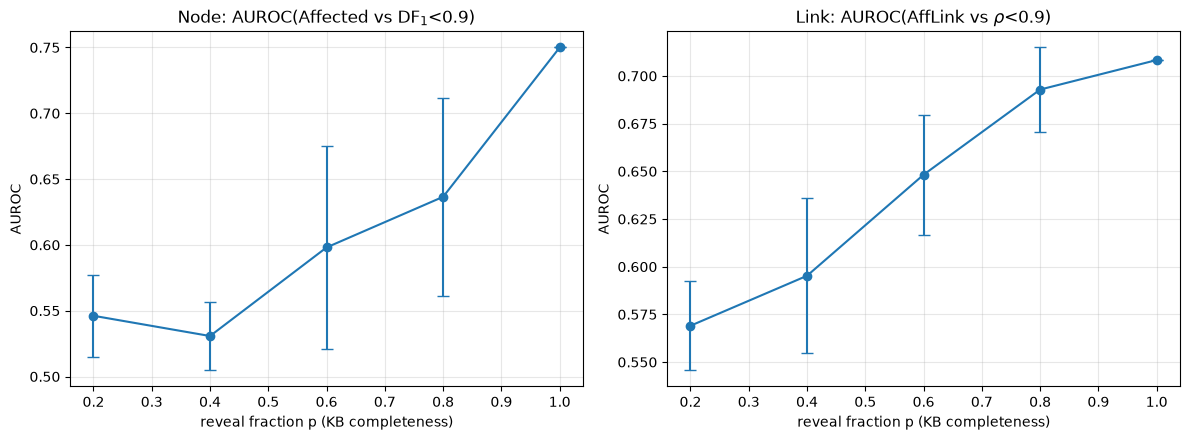

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, key, title in [(axes[0], "auroc_node", "Node: AUROC(Affected vs DF$_1$<0.9)"),
                       (axes[1], "auroc_link", "Link: AUROC(AffLink vs $\\rho$<0.9)")]:
    mus = [np.mean([m[key] for m in results[p]]) for p in fracs]
    sds = [np.std([m[key] for m in results[p]]) for p in fracs]
    ax.errorbar(fracs, mus, yerr=sds, marker="o", capsize=4)
    ax.set_xlabel("reveal fraction p (KB completeness)")
    ax.set_ylabel("AUROC")
    ax.set_title(title)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
